## Type classification

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
# Define functions for filtering small categories
def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    print(f"Original number of categories: {len(data['Device Name'].unique())}, Number of categories after screening: {len(classes_to_keep)}")
    print(f"Original sample size: {len(data)}, Number of samples after screening: {len(filtered_data)}")
    return filtered_data

# Setting parameters and file paths
base_dir = os.getcwd()
input_folder = os.path.join(base_dir, "6-Merged_Data", "6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "8-Quantized_Data",  "Quantized_values")
file_name = "Topology_B_fix_duration_5s.csv"
original_file_path = os.path.join(input_folder, file_name)
new_file_name = file_name.replace(".csv", "")

os.makedirs(input_folder, exist_ok=True)
os.makedirs(quantized_folder, exist_ok=True)

b_values = list(range(1, 17)) + [32, 64]
file_paths = {f"b{b}": os.path.join(quantized_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = original_file_path

if not os.path.exists(original_file_path):
    raise FileNotFoundError(f"non-existent: {original_file_path}")

original_data = pd.read_csv(file_paths["Original"])

# original_data = filter_small_classes(original_data, min_samples=15)

categories = original_data["Device Type"].unique()

y_orig = pd.Categorical(original_data["Device Type"], categories=categories).codes
X_orig = original_data.drop(columns=["Device Name", "Device Type", "File Name"])

k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)


f1_curve1 = {f"b{b}": [] for b in b_values}  # Raw data training, quantitative data testing
f1_curve2 = {f"b{b}": [] for b in b_values}  # Quantitative data training + testing

fold_count = 1
for train_idx, test_idx in kf.split(X_orig, y_orig):
    X_train_orig, X_test_orig = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_train_orig, y_test_orig = np.array(y_orig)[train_idx], np.array(y_orig)[test_idx]

    train_indices = X_orig.index[train_idx]
    test_indices = X_orig.index[test_idx]

    class_weights_orig = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_orig), y=y_train_orig)
    class_weight_dict_orig = {i: weight for i, weight in enumerate(class_weights_orig)}
    sample_weights = np.array([class_weights_orig[i] for i in y_train_orig])
    # Train XGBoost model
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',  # For multi-class classification
        use_label_encoder=False,
        colsample_bytree=0.4,
        gamma=0,
        learning_rate=0.2,
        max_depth=8,
        min_child_weight=0.5,
        n_estimators=300,
        subsample=1
    )
    
    xgb_model.fit(X_train_orig, y_train_orig, sample_weight=sample_weights)

    # rf_orig = RandomForestClassifier(random_state=42, class_weight=class_weight_dict_orig)
    # rf_orig.fit(X_train_orig, y_train_orig)

    # Curve 1
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Type"].isin(categories)].copy()

        try:
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Type"], categories=categories).codes

            y_pred = xgb_model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve1[b_key].append(f1)
        except KeyError:
            continue

    # Curve 2
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Type"].isin(categories)].copy()

        try:
            X_train = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[train_indices]
            y_train = pd.Categorical(data.loc[train_indices, "Device Type"], categories=categories).codes
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Type"], categories=categories).codes

            class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
            class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
            sample_weights = np.array([class_weights_orig[i] for i in y_train])
            
            xgb_model = XGBClassifier(
                random_state=42,
                eval_metric='mlogloss',  # For multi-class classification
                use_label_encoder=False,
                colsample_bytree=0.4,
                gamma=0,
                learning_rate=0.2,
                max_depth=8,
                min_child_weight=0.5,
                n_estimators=300,
                subsample=1
            )

            xgb_model.fit(X_train, y_train, sample_weight=sample_weights)


            y_pred = xgb_model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve2[b_key].append(f1)
        except (KeyError, ValueError):
            continue

    fold_count += 1

# Calculation of mean and standard deviation
f1_avg1 = {b_key: np.mean(scores) for b_key, scores in f1_curve1.items() if scores}
f1_std1 = {b_key: np.std(scores) for b_key, scores in f1_curve1.items() if scores}
f1_avg2 = {b_key: np.mean(scores) for b_key, scores in f1_curve2.items() if scores}
f1_std2 = {b_key: np.std(scores) for b_key, scores in f1_curve2.items() if scores}

# output result
print("Raw training + quantitative testing:")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg1:
        print(f"b={b}: {f1_avg1[b_key]:.4f} ± {f1_std1[b_key]:.4f}")

print("\nQuantitative training + Quantitative testing：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg2:
        print(f"b={b}: {f1_avg2[b_key]:.4f} ± {f1_std2[b_key]:.4f}")

plt.figure(figsize=(10, 6))
plt.errorbar(b_values, [f1_avg1[f"b{b}"] if f"b{b}" in f1_avg1 else 0 for b in b_values],
             yerr=[f1_std1[f"b{b}"] if f"b{b}" in f1_std1 else 0 for b in b_values],
             label="Original train + Quantized test", fmt='-o')
plt.errorbar(b_values, [f1_avg2[f"b{b}"] if f"b{b}" in f1_avg2 else 0 for b in b_values],
             yerr=[f1_std2[f"b{b}"] if f"b{b}" in f1_std2 else 0 for b in b_values],
             label="Quantized train + test", fmt='-s',color = "r")
plt.xlabel("Quantization bit width (b)")
plt.ylabel("Weighted F1-score")
plt.title("Comparison of F1-score under different quantization bit-widths (Type)")
plt.xticks(b_values[::2])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
# Save the figure
result_dir = os.path.join(base_dir, "9-different b Results")
os.makedirs(result_dir, exist_ok=True)
plt.savefig(os.path.join(result_dir, "quantization_f1_comparison_filtered_Type.png"))
plt.show()


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:04:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:04:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:05:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:05:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:02:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:02:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:02:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/antonio/.local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [20:03:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/antonio/.local/lib/python3.12/site-packages/xgboost/tr

Raw training + quantitative testing:
b=1: 0.1300 ± 0.0298
b=2: 0.1470 ± 0.0042
b=3: 0.4089 ± 0.0199
b=4: 0.4748 ± 0.0156
b=5: 0.5535 ± 0.0210
b=6: 0.6792 ± 0.0526
b=7: 0.7044 ± 0.0333
b=8: 0.7300 ± 0.0294
b=9: 0.7762 ± 0.0529
b=10: 0.7916 ± 0.0460
b=11: 0.6698 ± 0.0239
b=12: 0.8098 ± 0.0300
b=13: 0.8193 ± 0.0574
b=14: 0.8075 ± 0.0462
b=15: 0.9262 ± 0.0167
b=16: 0.8342 ± 0.0208
b=32: 0.9503 ± 0.0162
b=64: 0.9488 ± 0.0178

Quantitative training + Quantitative testing：
b=1: 0.3579 ± 0.0040
b=2: 0.5478 ± 0.0165
b=3: 0.6856 ± 0.0143
b=4: 0.8399 ± 0.0139
b=5: 0.8575 ± 0.0191
b=6: 0.8624 ± 0.0192
b=7: 0.8693 ± 0.0173
b=8: 0.8731 ± 0.0205
b=9: 0.9082 ± 0.0230
b=10: 0.9139 ± 0.0233
b=11: 0.9262 ± 0.0201
b=12: 0.9375 ± 0.0129
b=13: 0.9401 ± 0.0118
b=14: 0.9440 ± 0.0162
b=15: 0.9472 ± 0.0143
b=16: 0.9478 ± 0.0139
b=32: 0.9458 ± 0.0155
b=64: 0.9458 ± 0.0155


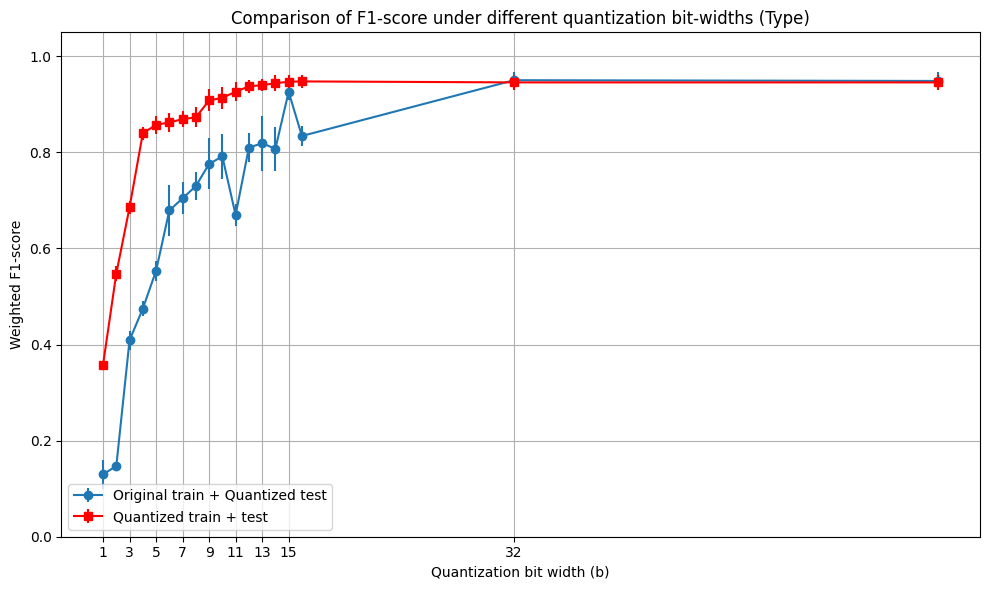

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
# Define functions for filtering small categories
def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    print(f"Original number of categories: {len(data['Device Name'].unique())}, Number of categories after screening: {len(classes_to_keep)}")
    print(f"Original sample size: {len(data)}, Number of samples after screening: {len(filtered_data)}")
    return filtered_data

# Setting parameters and file paths
base_dir = os.getcwd()
input_folder = os.path.join(base_dir, "6-Merged_Data", "6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "8-Quantized_Data",  "Quantized_values")
file_name = "Topology_B_fix_duration_5s.csv"
original_file_path = os.path.join(input_folder, file_name)
new_file_name = file_name.replace(".csv", "")

os.makedirs(input_folder, exist_ok=True)
os.makedirs(quantized_folder, exist_ok=True)

b_values = list(range(1, 17)) + [32, 64]
file_paths = {f"b{b}": os.path.join(quantized_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = original_file_path

if not os.path.exists(original_file_path):
    raise FileNotFoundError(f"non-existent: {original_file_path}")

original_data = pd.read_csv(file_paths["Original"])

# original_data = filter_small_classes(original_data, min_samples=15)

categories = original_data["Device Type"].unique()

y_orig = pd.Categorical(original_data["Device Type"], categories=categories).codes
X_orig = original_data.drop(columns=["Device Name", "Device Type", "File Name"])

k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)


f1_curve1 = {f"b{b}": [] for b in b_values}  # Raw data training, quantitative data testing
f1_curve2 = {f"b{b}": [] for b in b_values}  # Quantitative data training + testing

fold_count = 1
for train_idx, test_idx in kf.split(X_orig, y_orig):
    X_train_orig, X_test_orig = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_train_orig, y_test_orig = np.array(y_orig)[train_idx], np.array(y_orig)[test_idx]

    train_indices = X_orig.index[train_idx]
    test_indices = X_orig.index[test_idx]

    class_weights_orig = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_orig), y=y_train_orig)
    class_weight_dict_orig = {i: weight for i, weight in enumerate(class_weights_orig)}
    sample_weights = np.array([class_weights_orig[i] for i in y_train_orig])
    # Train XGBoost model
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',  # For multi-class classification
        use_label_encoder=False,
        colsample_bytree=0.4,
        gamma=0,
        learning_rate=0.2,
        max_depth=8,
        min_child_weight=0.5,
        n_estimators=300,
        subsample=1
    )
    
    xgb_model.fit(X_train_orig, y_train_orig, sample_weight=sample_weights)

    # rf_orig = RandomForestClassifier(random_state=42, class_weight=class_weight_dict_orig)
    # rf_orig.fit(X_train_orig, y_train_orig)

    # Curve 1
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Type"].isin(categories)].copy()

        try:
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Type"], categories=categories).codes

            y_pred = xgb_model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='macro')
            f1_curve1[b_key].append(f1)
        except KeyError:
            continue

    # Curve 2
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data = data[data["Device Type"].isin(categories)].copy()

        try:
            X_train = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[train_indices]
            y_train = pd.Categorical(data.loc[train_indices, "Device Type"], categories=categories).codes
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Type"], categories=categories).codes

            class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
            class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
            sample_weights = np.array([class_weights_orig[i] for i in y_train])
            
            xgb_model = XGBClassifier(
                random_state=42,
                eval_metric='mlogloss',  # For multi-class classification
                use_label_encoder=False,
                colsample_bytree=0.4,
                gamma=0,
                learning_rate=0.2,
                max_depth=8,
                min_child_weight=0.5,
                n_estimators=300,
                subsample=1
            )

            xgb_model.fit(X_train, y_train, sample_weight=sample_weights)


            y_pred = xgb_model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='macro')
            f1_curve2[b_key].append(f1)
        except (KeyError, ValueError):
            continue

    fold_count += 1

# Calculation of mean and standard deviation
f1_avg1 = {b_key: np.mean(scores) for b_key, scores in f1_curve1.items() if scores}
f1_std1 = {b_key: np.std(scores) for b_key, scores in f1_curve1.items() if scores}
f1_avg2 = {b_key: np.mean(scores) for b_key, scores in f1_curve2.items() if scores}
f1_std2 = {b_key: np.std(scores) for b_key, scores in f1_curve2.items() if scores}

# output result
print("Raw training + quantitative testing:")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg1:
        print(f"b={b}: {f1_avg1[b_key]:.4f} ± {f1_std1[b_key]:.4f}")

print("\nQuantitative training + Quantitative testing：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg2:
        print(f"b={b}: {f1_avg2[b_key]:.4f} ± {f1_std2[b_key]:.4f}")

plt.figure(figsize=(10, 6))
plt.errorbar(b_values, [f1_avg1[f"b{b}"] if f"b{b}" in f1_avg1 else 0 for b in b_values],
             yerr=[f1_std1[f"b{b}"] if f"b{b}" in f1_std1 else 0 for b in b_values],
             label="Original train + Quantized test", fmt='-o')
plt.errorbar(b_values, [f1_avg2[f"b{b}"] if f"b{b}" in f1_avg2 else 0 for b in b_values],
             yerr=[f1_std2[f"b{b}"] if f"b{b}" in f1_std2 else 0 for b in b_values],
             label="Quantized train + test", fmt='-s',color = "r")
plt.xlabel("Quantization bit width (b)")
plt.ylabel("Weighted F1-score")
plt.title("Comparison of F1-score under different quantization bit-widths (Type)")
plt.xticks(b_values[::2])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
# Save the figure
result_dir = os.path.join(base_dir, "9-different b Results")
os.makedirs(result_dir, exist_ok=True)
plt.savefig(os.path.join(result_dir, "quantization_f1_comparison_filtered_Type.png"))
plt.show()


## Name classification

Original number of categories: 19, Number of categories after screening: 14
Original sample size: 31029, Number of samples after screening: 19764
Raw training + quantitative testing:
b=1: 0.4756 ± 0.0101
b=2: 0.5295 ± 0.0192
b=3: 0.5968 ± 0.0072
b=4: 0.7621 ± 0.0045
b=5: 0.8522 ± 0.0132
b=6: 0.9222 ± 0.0010
b=7: 0.9394 ± 0.0044
b=8: 0.9447 ± 0.0013
b=9: 0.9485 ± 0.0030
b=10: 0.9560 ± 0.0021
b=11: 0.9582 ± 0.0028
b=12: 0.9613 ± 0.0044
b=13: 0.9651 ± 0.0033
b=14: 0.9646 ± 0.0031
b=15: 0.9671 ± 0.0013
b=16: 0.9676 ± 0.0035
b=32: 0.9719 ± 0.0020
b=64: 0.9719 ± 0.0020

Quantitative training + Quantitative testing：
b=1: 0.7008 ± 0.0132
b=2: 0.8496 ± 0.0027
b=3: 0.9126 ± 0.0028
b=4: 0.9376 ± 0.0023
b=5: 0.9444 ± 0.0024
b=6: 0.9473 ± 0.0021
b=7: 0.9483 ± 0.0026
b=8: 0.9511 ± 0.0021
b=9: 0.9567 ± 0.0020
b=10: 0.9599 ± 0.0023
b=11: 0.9611 ± 0.0024
b=12: 0.9619 ± 0.0026
b=13: 0.9646 ± 0.0028
b=14: 0.9650 ± 0.0028
b=15: 0.9686 ± 0.0027
b=16: 0.9694 ± 0.0021
b=32: 0.9710 ± 0.0021
b=64: 0.9710 ± 0.0

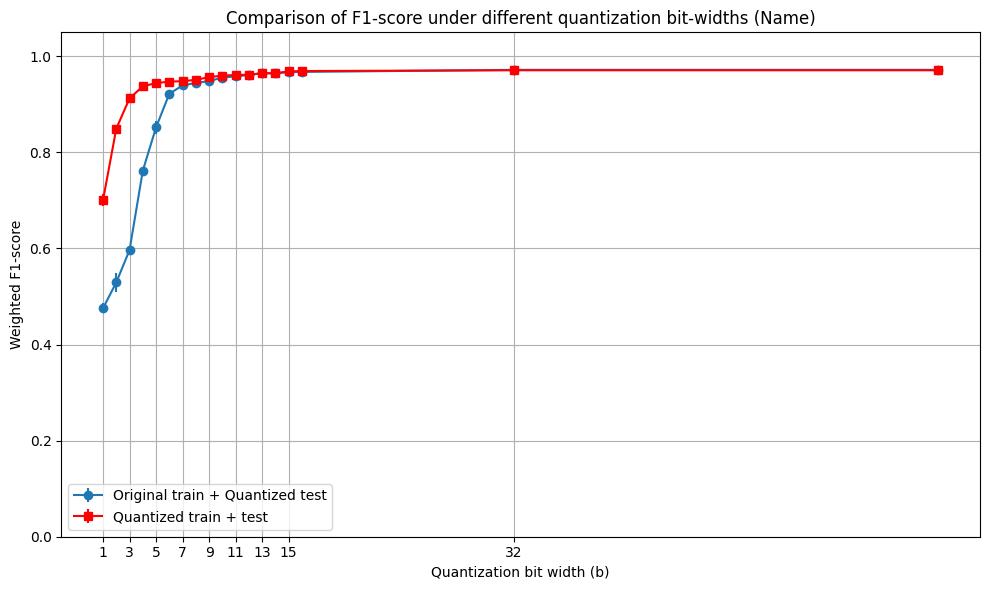

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import re

def filter_small_classes(data, col_name = "Device Name", min_samples=5):
    class_counts = data[col_name].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    print(f"Original number of categories: {len(data['Device Name'].unique())}, Number of categories after screening: {len(classes_to_keep)}")
    print(f"Original sample size: {len(data)}, Number of samples after screening: {len(filtered_data)}")
    return filtered_data

def generalize_device_name(name):
    """Remove trailing numbers and spaces from device name"""
    # Remove trailing digits and spaces (e.g., "Device 1" -> "Device", "Camera2" -> "Camera")
    generalized = re.sub(r'\s*\d+\s*$', '', str(name)).strip()
    return generalized

base_dir = os.getcwd()
input_folder = os.path.join(base_dir, "6-Merged_Data", "6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "8-Quantized_Data",  "Quantized_values")
file_name = "Topology_B_fix_duration_5s.csv"
original_file_path = os.path.join(input_folder, file_name)
new_file_name = file_name.replace(".csv", "")


os.makedirs(input_folder, exist_ok=True)
os.makedirs(quantized_folder, exist_ok=True)


b_values = list(range(1, 17)) + [32, 64]
file_paths = {f"b{b}": os.path.join(quantized_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = original_file_path


if not os.path.exists(original_file_path):
    raise FileNotFoundError(f"non-existence: {original_file_path}")


original_data = pd.read_csv(file_paths["Original"])


original_data["Device Name General"] = original_data["Device Name"].apply(generalize_device_name)


original_data = filter_small_classes(original_data, col_name="Device Name General", min_samples=10)


categories = original_data["Device Name General"].unique()


y_orig = pd.Categorical(original_data["Device Name General"], categories=categories).codes
X_orig = original_data.drop(columns=["Device Name", "Device Type", "File Name", "Device Name General"])


k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)


f1_curve1 = {f"b{b}": [] for b in b_values}  # Raw data training, quantitative data testing
f1_curve2 = {f"b{b}": [] for b in b_values}  # Quantitative data training + testing


fold_count = 1
for train_idx, test_idx in kf.split(X_orig, y_orig):

    X_train_orig, X_test_orig = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_train_orig, y_test_orig = np.array(y_orig)[train_idx], np.array(y_orig)[test_idx]


    train_indices = X_orig.index[train_idx]
    test_indices = X_orig.index[test_idx]


    class_weights_orig = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_orig), y=y_train_orig)
    class_weight_dict_orig = {i: weight for i, weight in enumerate(class_weights_orig)}

    rf_orig = RandomForestClassifier(random_state=42, class_weight=class_weight_dict_orig)
    rf_orig.fit(X_train_orig, y_train_orig)

    # Curve 1：
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data["Device Name General"] = data["Device Name"].apply(generalize_device_name)

        data = data[data["Device Name General"].isin(categories)].copy()

        try:
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name", "Device Name General"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Name General"], categories=categories).codes

            y_pred = rf_orig.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve1[b_key].append(f1)
        except KeyError:
            continue

    # curve 2：
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data["Device Name General"] = data["Device Name"].apply(generalize_device_name)
        data = data[data["Device Name General"].isin(categories)].copy()


        try:
            X_train = data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"]).loc[train_indices]
            y_train = pd.Categorical(data.loc[train_indices, "Device Name General"], categories=categories).codes
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Name General"], categories=categories).codes

            class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
            class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

            rf = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
            rf.fit(X_train, y_train)

            y_pred = rf.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            f1_curve2[b_key].append(f1)
        except (KeyError, ValueError):
            continue

    fold_count += 1

# Calculation of mean and standard deviation
f1_avg1 = {b_key: np.mean(scores) for b_key, scores in f1_curve1.items() if scores}
f1_std1 = {b_key: np.std(scores) for b_key, scores in f1_curve1.items() if scores}
f1_avg2 = {b_key: np.mean(scores) for b_key, scores in f1_curve2.items() if scores}
f1_std2 = {b_key: np.std(scores) for b_key, scores in f1_curve2.items() if scores}

# output result
print("Raw training + quantitative testing:")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg1:
        print(f"b={b}: {f1_avg1[b_key]:.4f} ± {f1_std1[b_key]:.4f}")

print("\nQuantitative training + Quantitative testing：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg2:
        print(f"b={b}: {f1_avg2[b_key]:.4f} ± {f1_std2[b_key]:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.errorbar(b_values, [f1_avg1[f"b{b}"] if f"b{b}" in f1_avg1 else 0 for b in b_values],
             yerr=[f1_std1[f"b{b}"] if f"b{b}" in f1_std1 else 0 for b in b_values],
             label="Original train + Quantized test", fmt='-o')
plt.errorbar(b_values, [f1_avg2[f"b{b}"] if f"b{b}" in f1_avg2 else 0 for b in b_values],
             yerr=[f1_std2[f"b{b}"] if f"b{b}" in f1_std2 else 0 for b in b_values],
             label="Quantized train + test", fmt='-s',color = "r")
plt.xlabel("Quantization bit width (b)")
plt.ylabel("Weighted F1-score")
plt.title("Comparison of F1-score under different quantization bit-widths (Name)")
plt.xticks(b_values[::2])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the figure
result_dir = os.path.join(base_dir, "9-different b Results")
os.makedirs(result_dir, exist_ok=True)
plt.savefig(os.path.join(result_dir, "quantization_f1_comparison_filtered_Name.png"))
plt.show()


Original number of categories: 19, Number of categories after screening: 14
Original sample size: 31029, Number of samples after screening: 19764
Raw training + quantitative testing:
b=1: 0.1021 ± 0.0045
b=2: 0.1292 ± 0.0098
b=3: 0.1572 ± 0.0068
b=4: 0.3623 ± 0.0223
b=5: 0.4923 ± 0.0161
b=6: 0.6879 ± 0.0200
b=7: 0.7397 ± 0.0222
b=8: 0.8445 ± 0.0229
b=9: 0.8733 ± 0.0139
b=10: 0.9088 ± 0.0085
b=11: 0.9145 ± 0.0074
b=12: 0.9201 ± 0.0098
b=13: 0.9243 ± 0.0090
b=14: 0.9256 ± 0.0084
b=15: 0.9277 ± 0.0075
b=16: 0.9278 ± 0.0083
b=32: 0.9308 ± 0.0083
b=64: 0.9308 ± 0.0083

Quantitative training + Quantitative testing：
b=1: 0.3188 ± 0.0138
b=2: 0.5861 ± 0.0176
b=3: 0.7116 ± 0.0215
b=4: 0.8364 ± 0.0071
b=5: 0.8564 ± 0.0059
b=6: 0.8648 ± 0.0035
b=7: 0.8602 ± 0.0137
b=8: 0.8740 ± 0.0076
b=9: 0.8880 ± 0.0060
b=10: 0.9185 ± 0.0097
b=11: 0.9195 ± 0.0089
b=12: 0.9207 ± 0.0116
b=13: 0.9233 ± 0.0103
b=14: 0.9246 ± 0.0094
b=15: 0.9269 ± 0.0099
b=16: 0.9268 ± 0.0078
b=32: 0.9267 ± 0.0115
b=64: 0.9267 ± 0.0

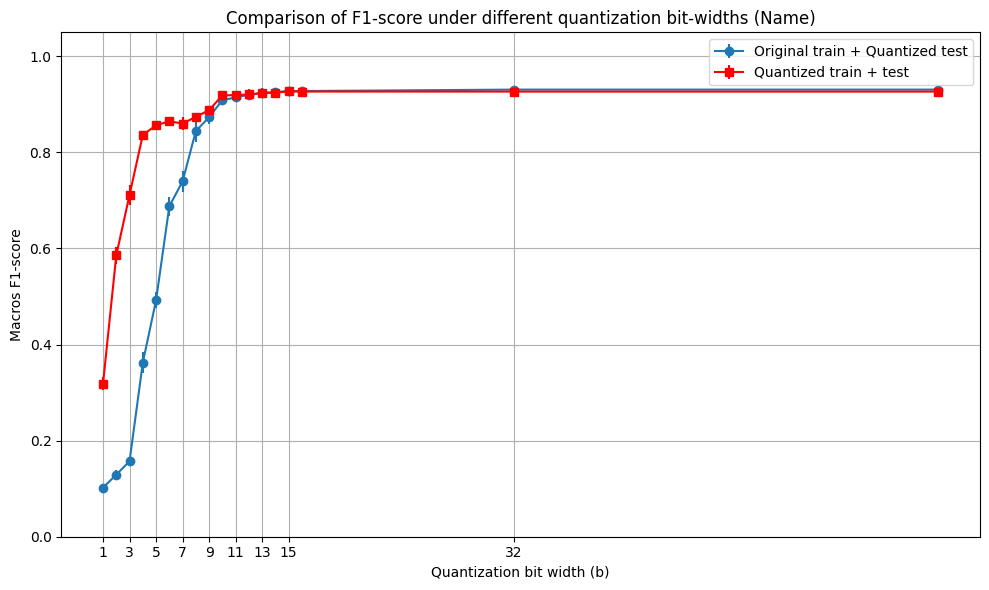

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import re

def filter_small_classes(data, col_name = "Device Name", min_samples=5):
    class_counts = data[col_name].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    print(f"Original number of categories: {len(data['Device Name'].unique())}, Number of categories after screening: {len(classes_to_keep)}")
    print(f"Original sample size: {len(data)}, Number of samples after screening: {len(filtered_data)}")
    return filtered_data

def generalize_device_name(name):
    """Remove trailing numbers and spaces from device name"""
    # Remove trailing digits and spaces (e.g., "Device 1" -> "Device", "Camera2" -> "Camera")
    generalized = re.sub(r'\s*\d+\s*$', '', str(name)).strip()
    return generalized

base_dir = os.getcwd()
input_folder = os.path.join(base_dir, "6-Merged_Data", "6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "8-Quantized_Data",  "Quantized_values")
file_name = "Topology_B_fix_duration_5s.csv"
original_file_path = os.path.join(input_folder, file_name)
new_file_name = file_name.replace(".csv", "")


os.makedirs(input_folder, exist_ok=True)
os.makedirs(quantized_folder, exist_ok=True)


b_values = list(range(1, 17)) + [32, 64]
file_paths = {f"b{b}": os.path.join(quantized_folder, f"{new_file_name}_value_b{b}.csv") for b in b_values}
file_paths["Original"] = original_file_path


if not os.path.exists(original_file_path):
    raise FileNotFoundError(f"non-existence: {original_file_path}")


original_data = pd.read_csv(file_paths["Original"])


original_data["Device Name General"] = original_data["Device Name"].apply(generalize_device_name)


original_data = filter_small_classes(original_data, col_name="Device Name General", min_samples=10)


categories = original_data["Device Name General"].unique()


y_orig = pd.Categorical(original_data["Device Name General"], categories=categories).codes
X_orig = original_data.drop(columns=["Device Name", "Device Type", "File Name", "Device Name General"])


k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)


f1_curve1 = {f"b{b}": [] for b in b_values}  # Raw data training, quantitative data testing
f1_curve2 = {f"b{b}": [] for b in b_values}  # Quantitative data training + testing


fold_count = 1
for train_idx, test_idx in kf.split(X_orig, y_orig):

    X_train_orig, X_test_orig = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_train_orig, y_test_orig = np.array(y_orig)[train_idx], np.array(y_orig)[test_idx]


    train_indices = X_orig.index[train_idx]
    test_indices = X_orig.index[test_idx]


    class_weights_orig = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_orig), y=y_train_orig)
    class_weight_dict_orig = {i: weight for i, weight in enumerate(class_weights_orig)}

    rf_orig = RandomForestClassifier(random_state=42, class_weight=class_weight_dict_orig)
    rf_orig.fit(X_train_orig, y_train_orig)

    # Curve 1：
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data["Device Name General"] = data["Device Name"].apply(generalize_device_name)

        data = data[data["Device Name General"].isin(categories)].copy()

        try:
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name", "Device Name General"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Name General"], categories=categories).codes

            y_pred = rf_orig.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='macro')
            f1_curve1[b_key].append(f1)
        except KeyError:
            continue

    # curve 2：
    for b in b_values:
        b_key = f"b{b}"
        data = pd.read_csv(file_paths[b_key])
        data["Device Name General"] = data["Device Name"].apply(generalize_device_name)
        data = data[data["Device Name General"].isin(categories)].copy()


        try:
            X_train = data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"]).loc[train_indices]
            y_train = pd.Categorical(data.loc[train_indices, "Device Name General"], categories=categories).codes
            X_test = data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"]).loc[test_indices]
            y_test = pd.Categorical(data.loc[test_indices, "Device Name General"], categories=categories).codes

            class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
            class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

            rf = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
            rf.fit(X_train, y_train)

            y_pred = rf.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='macro')
            f1_curve2[b_key].append(f1)
        except (KeyError, ValueError):
            continue

    fold_count += 1

# Calculation of mean and standard deviation
f1_avg1 = {b_key: np.mean(scores) for b_key, scores in f1_curve1.items() if scores}
f1_std1 = {b_key: np.std(scores) for b_key, scores in f1_curve1.items() if scores}
f1_avg2 = {b_key: np.mean(scores) for b_key, scores in f1_curve2.items() if scores}
f1_std2 = {b_key: np.std(scores) for b_key, scores in f1_curve2.items() if scores}

# output result
print("Raw training + quantitative testing:")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg1:
        print(f"b={b}: {f1_avg1[b_key]:.4f} ± {f1_std1[b_key]:.4f}")

print("\nQuantitative training + Quantitative testing：")
for b in b_values:
    b_key = f"b{b}"
    if b_key in f1_avg2:
        print(f"b={b}: {f1_avg2[b_key]:.4f} ± {f1_std2[b_key]:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.errorbar(b_values, [f1_avg1[f"b{b}"] if f"b{b}" in f1_avg1 else 0 for b in b_values],
             yerr=[f1_std1[f"b{b}"] if f"b{b}" in f1_std1 else 0 for b in b_values],
             label="Original train + Quantized test", fmt='-o')
plt.errorbar(b_values, [f1_avg2[f"b{b}"] if f"b{b}" in f1_avg2 else 0 for b in b_values],
             yerr=[f1_std2[f"b{b}"] if f"b{b}" in f1_std2 else 0 for b in b_values],
             label="Quantized train + test", fmt='-s',color = "r")
plt.xlabel("Quantization bit width (b)")
plt.ylabel("Macros F1-score")
plt.title("Comparison of F1-score under different quantization bit-widths (Name)")
plt.xticks(b_values[::2])
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the figure
result_dir = os.path.join(base_dir, "9-different b Results")
os.makedirs(result_dir, exist_ok=True)
plt.savefig(os.path.join(result_dir, "quantization_f1_comparison_filtered_Name.png"))
plt.show()
